# Souq Ecommerce Buisness Performance

## Life Cycle of ML Project

- Understanding the Problem Statement
- Data Collection
- Data checks to perform
- Exploratory Data Analysis
- Data pre processing
- Model Training
- Chose best Model

## 1) Problem Statement

To understand the buisness, its trends and revenue over a period of time and to predict its upcoming sales trends.

## 2) Data Collection

- Dataset source- https://www.kaggle.com
- Our Dataset has 15 Columns

#Importing Data and Required Libraries

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#Import CSV to pd-DataFrame

In [196]:
df = pd.read_csv('Souq_Ecommerce_raw_data.csv')

In [197]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Source,Product_Category,Product_Name,Quantity_Purchased,Unit_Price,Total_Sales,Payment_Method,Year,Month,Month_Name,Weekday
0,ORD-2022-00001,9-Dec-22,C0273,P0150,"Polaroid Sunglasses for Unisex , Blue",Eyewear,"Polaroid Sunglasses for Unisex , Blue",1,250.00,250.0,COD,2022,12,December,Friday
1,ORD-2025-00002,24-Mar-25,C0212,P0569,Casio Men Black Dial Resin Band Watch aeq-110b...,Watches,Casio Men Black Dial Resin Band Watch aeq-110b...,6,313.95,1883.7,Net Banking,2025,3,March,Monday
2,ORD-2022-00003,27-Jun-22,C0666,P0009,Nike Air Zoom Pegasus 36 Running Sneakers for ...,Athletic Shoes,Nike Air Zoom Pegasus 36 Running Sneakers for ...,2,609.00,1218.0,COD,2022,6,June,Monday
3,ORD-2022-00004,21-Mar-22,C0541,P0175,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",Eyewear,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",1,820.00,820.0,UPI,2022,3,March,Monday
4,ORD-2022-00005,29-Jul-22,C0322,P0272,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",Eyewear,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",2,279.00,558.0,Debit Card,2022,7,July,Friday


In [198]:
df.shape

(3000, 15)

## 2.1) Dataset Information

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            3000 non-null   object 
 1   Order_Date          3000 non-null   object 
 2   Customer_ID         3000 non-null   object 
 3   Product_ID          3000 non-null   object 
 4   Product_Source      3000 non-null   object 
 5   Product_Category    3000 non-null   object 
 6   Product_Name        3000 non-null   object 
 7   Quantity_Purchased  3000 non-null   int64  
 8   Unit_Price          3000 non-null   float64
 9   Total_Sales         3000 non-null   float64
 10  Payment_Method      3000 non-null   object 
 11  Year                3000 non-null   int64  
 12  Month               3000 non-null   int64  
 13  Month_Name          3000 non-null   object 
 14  Weekday             3000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 351.7

## 3) Data Checks to perform

- Missing Values
- Duplicate Values
- Data Types
- Unique Values
- check statistics of the dataset
- check various categories  
- Adding 'Average Sales' column to the dataset

#1)Missing Values

In [200]:
df.isna().sum()

Order_ID              0
Order_Date            0
Customer_ID           0
Product_ID            0
Product_Source        0
Product_Category      0
Product_Name          0
Quantity_Purchased    0
Unit_Price            0
Total_Sales           0
Payment_Method        0
Year                  0
Month                 0
Month_Name            0
Weekday               0
dtype: int64

There are no missing values in our dataset

#2)Duplicate Values

In [201]:
df.duplicated().sum()

np.int64(0)

Our Dataset contains Unique Values

#3)Data Types

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            3000 non-null   object 
 1   Order_Date          3000 non-null   object 
 2   Customer_ID         3000 non-null   object 
 3   Product_ID          3000 non-null   object 
 4   Product_Source      3000 non-null   object 
 5   Product_Category    3000 non-null   object 
 6   Product_Name        3000 non-null   object 
 7   Quantity_Purchased  3000 non-null   int64  
 8   Unit_Price          3000 non-null   float64
 9   Total_Sales         3000 non-null   float64
 10  Payment_Method      3000 non-null   object 
 11  Year                3000 non-null   int64  
 12  Month               3000 non-null   int64  
 13  Month_Name          3000 non-null   object 
 14  Weekday             3000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 351.7

Date time columns must be changed to respective types.

#4)Unique Values

In [203]:
df.nunique()

Order_ID              3000
Order_Date            1102
Customer_ID            663
Product_ID             607
Product_Source         602
Product_Category         7
Product_Name           602
Quantity_Purchased      10
Unit_Price             451
Total_Sales           1093
Payment_Method           6
Year                     4
Month                   12
Month_Name              12
Weekday                  7
dtype: int64

#5)Statistics of Dataset

In [204]:
df.describe()

,Quantity_Purchased,Unit_Price,Total_Sales,Year,Month
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.240333,1012.587243,2280.527773,2023.332333,7.075333
std,1.655744,2239.383946,7259.536376,1.004436,3.779826
min,1.000000,42.000000,45.000000,2022.000000,1.000000
25%,1.000000,279.000000,449.000000,2022.000000,4.000000
50%,2.000000,525.000000,984.930000,2023.000000,7.000000
75%,3.000000,1039.500000,2127.750000,2024.000000,11.000000
max,10.000000,29970.000000,239760.000000,2025.000000,12.000000


Since Year and Month are actually datetime, we dont consider them but looking into other neumerical columns we can see that-

- Average item price ≈ ₹1,000, but very high standard deviation → wide price range.

- Min ₹42 vs. max ₹29,970 means the catalog includes both low-cost and premium products.

- 25% = ₹279 and 75% = ₹1,039 → 50% of items are priced between ₹279 and ₹1,039 → bulk of sales are from affordable to mid-range products.

- Outliers (very high-priced items) push up the mean → distribution is right-skewed.

#6)Various Categories

Dataset Categories

In [205]:
df_category = df['Product_Category'].unique()
df_category

array(['Eyewear', 'Watches', 'Athletic Shoes', 'Casual & Dress Shoes',
       'Wallets', 'Perfumes & Fragrances', 'Sportswear'], dtype=object)

Neumerical Categories

In [206]:
df_nuemerical = [feature for feature in df.columns if df[feature].dtype != 'object']
df_nuemerical

['Quantity_Purchased', 'Unit_Price', 'Total_Sales', 'Year', 'Month']

Categorical Categories

In [207]:
df_categorical = [feature for feature in df.columns if df[feature].dtype == 'object']
df_categorical

['Order_ID',
 'Order_Date',
 'Customer_ID',
 'Product_ID',
 'Product_Source',
 'Product_Category',
 'Product_Name',
 'Payment_Method',
 'Month_Name',
 'Weekday']

#7)Adding 'Average Sales' column

In [208]:
df['Average_Sales'] = df['Total_Sales'] / df['Quantity_Purchased']
df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Source,Product_Category,Product_Name,Quantity_Purchased,Unit_Price,Total_Sales,Payment_Method,Year,Month,Month_Name,Weekday,Average_Sales
0,ORD-2022-00001,9-Dec-22,C0273,P0150,"Polaroid Sunglasses for Unisex , Blue",Eyewear,"Polaroid Sunglasses for Unisex , Blue",1,250.00,250.0,COD,2022,12,December,Friday,250.00
1,ORD-2025-00002,24-Mar-25,C0212,P0569,Casio Men Black Dial Resin Band Watch aeq-110b...,Watches,Casio Men Black Dial Resin Band Watch aeq-110b...,6,313.95,1883.7,Net Banking,2025,3,March,Monday,313.95
2,ORD-2022-00003,27-Jun-22,C0666,P0009,Nike Air Zoom Pegasus 36 Running Sneakers for ...,Athletic Shoes,Nike Air Zoom Pegasus 36 Running Sneakers for ...,2,609.00,1218.0,COD,2022,6,June,Monday,609.00
3,ORD-2022-00004,21-Mar-22,C0541,P0175,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",Eyewear,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",1,820.00,820.0,UPI,2022,3,March,Monday,820.00
4,ORD-2022-00005,29-Jul-22,C0322,P0272,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",Eyewear,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",2,279.00,558.0,Debit Card,2022,7,July,Friday,279.00


## 4)EDA & Data Visualization

- Category Column

- Total Sales Vs Average Sales Categorically

In [209]:
df_category_summary = df.groupby('Product_Category').agg({'Total_Sales': 'sum', 'Average_Sales': 'mean'})
df_category_summary

,Total_Sales,Average_Sales
Product_Category,,
Athletic Shoes,599708.02,574.506307
Casual & Dress Shoes,231879.00,448.327354
Eyewear,1339844.60,822.441551
Perfumes & Fragrances,257679.83,358.974928
Sportswear,135329.18,336.914335
Wallets,105869.00,301.093023
Watches,4171273.69,2051.925479


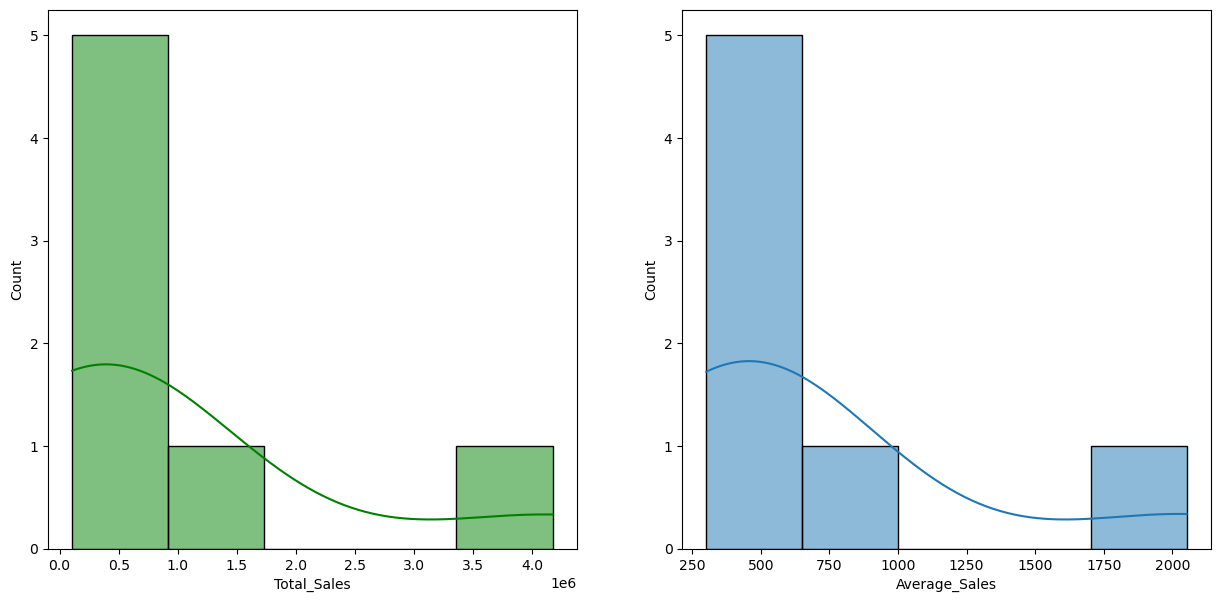

In [210]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121) 
sns.histplot(data= df_category_summary, x='Total_Sales',kde= True, color='g')
plt.subplot(122)
sns.histplot(data= df_category_summary, x= 'Average_Sales', kde= True)
plt.show()

Insights

- Right Skew in both plots mean that data is unevenly distributed and a few high performers dominate.

- Low overlap of high Total and high Average Sales 
- Most product categories have low-to-moderate sales.
- A few categories dominate in total revenue.

- Average sales per item vary moderately, with few high-value outliers.


- Top Categories that drive the buisness

In [211]:
df_DA = df.copy()
df_top_categories = df_DA.groupby('Product_Category')['Total_Sales'].agg('sum')
df_top_categories = df_top_categories.sort_values(ascending=False)
df_top_categories = pd.DataFrame(df_top_categories)
df_top_categories

,Total_Sales
Product_Category,
Watches,4171273.69
Eyewear,1339844.60
Athletic Shoes,599708.02
Perfumes & Fragrances,257679.83
Casual & Dress Shoes,231879.00
Sportswear,135329.18
Wallets,105869.00


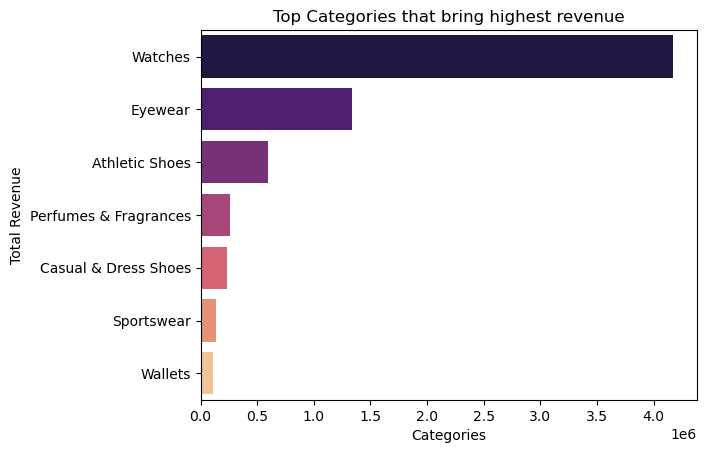

In [212]:
sns.barplot(data= df_top_categories, y= 'Product_Category',x = 'Total_Sales', palette='magma')
plt.title("Top Categories that bring highest revenue")
plt.xlabel("Categories")
plt.ylabel("Total Revenue")
plt.show()

Most Highest Category that influences the buisness are watches

- Category and the Payment Method bivariate analysis

In [213]:
df_DA_bivar = df_DA.pivot_table(index= 'Product_Category', columns= 'Payment_Method', values= 'Total_Sales', aggfunc= 'sum')
df_DA_bivar

Payment_Method,COD,Credit Card,Debit Card,Net Banking,UPI,Wallet
Product_Category,,,,,,
Athletic Shoes,84978.40,99957.69,103323.04,150339.62,85771.86,75337.41
Casual & Dress Shoes,43459.00,41355.00,34743.00,29487.00,48016.00,34819.00
Eyewear,255798.60,225628.80,194687.80,216681.10,234005.80,213042.50
Perfumes & Fragrances,23497.02,67185.51,44113.68,35997.86,43713.76,43172.00
Sportswear,11580.38,29038.49,12046.00,18661.16,45690.00,18313.15
Wallets,18607.00,16152.00,24609.00,11885.00,12109.00,22507.00
Watches,881295.03,810385.83,449896.68,682235.98,783359.80,564100.37


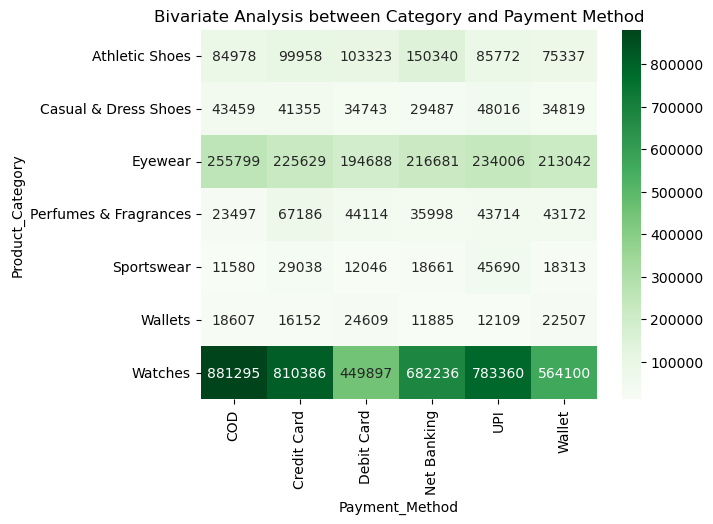

In [214]:
sns.heatmap(data= df_DA_bivar, annot=True, fmt='.0f', cmap= 'Greens')
plt.title("Bivariate Analysis between Category and Payment Method")
plt.show()

- Watches paid on COD, Credit Card and UPI are highest selling factors in the buisness

- Eyewear performs second across all methods

- Athletic Shoes is the 3rd performer

- Items Column

- Top Performing Items 

In [215]:
df_DA_prod = df.copy()

In [216]:
df_DA_prod = df[['Product_Name','Total_Sales']]
df_DA_prod = pd.DataFrame(df_DA_prod)
df_DA_prod

,Product_Name,Total_Sales
0,"Polaroid Sunglasses for Unisex , Blue",250.00
1,Casio Men Black Dial Resin Band Watch aeq-110b...,1883.70
2,Nike Air Zoom Pegasus 36 Running Sneakers for ...,1218.00
3,"Ray Ban Sunglasses for Men - Size 55, Black Fr...",820.00
4,"Flamingo Rectangle Sunglasseses For Unisex,Pla...",558.00
...,...,...
2995,Nike Court Vision Low Faux Leather Contrast Si...,8251.52
2996,Polaroid Sunglasses For Unisex Pld 2061/S00350...,250.00
2997,"Tommy Hilfiger Bifold Wallet For Men,Leather,B...",838.00
2998,Adidas Grand Court Base Faux Leather Contrast ...,518.00


In [217]:
df_DA_prod.nunique()

Product_Name     602
Total_Sales     1093
dtype: int64

In [ ]:
df_DA_items = df_DA.groupby('Product_Name')['Total_Sales'].agg('sum')
df_DA_items = df_DA_items.sort_values(ascending=False)
df_DA_items = df_DA_items.head()

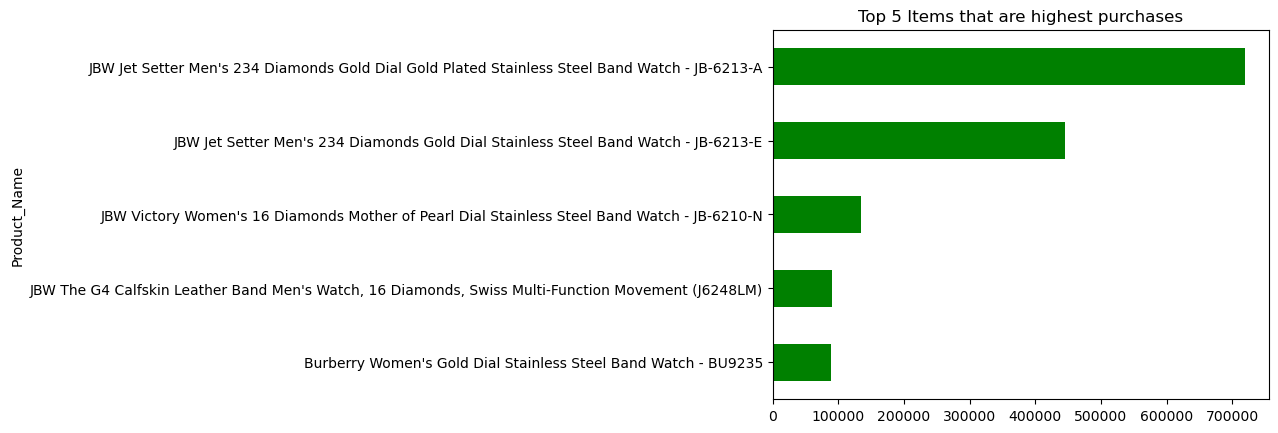

In [ ]:
df_DA_items[::-1].plot(kind='barh', x= 'Total_Sales', y= 'Product_Name', color='green')
plt.title("Top 5 Items that are highest purchases")
plt.show()

All top 5 items are watches

- Checking Outliers

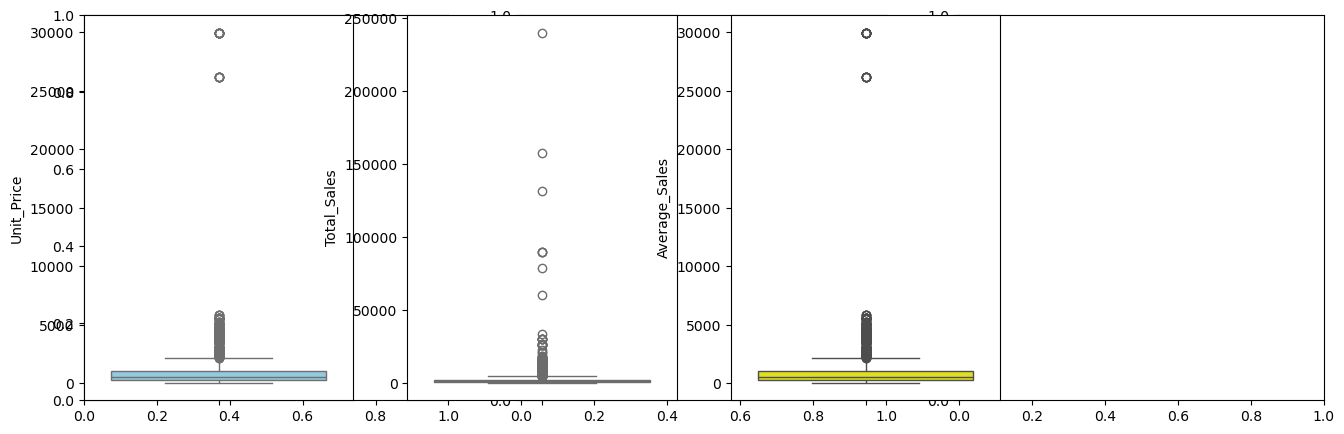

In [223]:
plt.subplots(1,3,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['Unit_Price'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['Total_Sales'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['Average_Sales'],color='yellow')
plt.show()

We have Multiple outliers